# RAG and Image Classification



**Import Libraries**

In [1]:
from langchain.document_loaders import PyPDFLoader
from langchain.text_splitter import CharacterTextSplitter
from langchain.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings, HuggingFacePipeline
from langchain.chains import RetrievalQA
from transformers import pipeline, AutoTokenizer

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time


## 1) Demonstrate LangChain with a suitable example involving RAG, input/output parsing, output formatting, etc.



In [3]:
# Load and Split PDF
pdf_path = "Machine Learning v5.pdf"
loader = PyPDFLoader(pdf_path)
pages = loader.load_and_split()

splitter = CharacterTextSplitter(chunk_size=300, chunk_overlap=50)
chunks = splitter.split_documents(pages)

# Embed and Store in FAISS Vector DB
embedding_model = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
db = FAISS.from_documents(chunks, embedding_model)

# Load LLM 
qa_pipeline = pipeline("text2text-generation", model="google/flan-t5-base", max_new_tokens=300)
llm = HuggingFacePipeline(pipeline=qa_pipeline)

# Create RAG
qa_chain = RetrievalQA.from_chain_type(llm=llm, retriever=db.as_retriever())

# Question
query = "Explain Knowledge Discovery in 2–3 simple sentences as if explaining to a beginner."

# Tokenize query for inspection
tokenizer = AutoTokenizer.from_pretrained("google/flan-t5-base")
tokenized_input = tokenizer(query, return_tensors="pt")
print("\n Parsed Input Tokens:", tokenized_input['input_ids'])

# Run RAG pipeline
response = qa_chain.invoke(query)

raw_output = response["result"]
final_output = raw_output.strip().replace("\n", " ")

# Results
print(f"\nQuery: {query}")
print(f"\nLLM Raw Output:", raw_output)
print(f"\nFinal Output:", final_output)


Device set to use cpu



 Parsed Input Tokens: tensor([[25488, 16113, 19499,    16,   204,   104,   519,   650, 16513,    38,
             3,    99, 13834,    12,     3,     9, 19529,     5,     1]])

Query: Explain Knowledge Discovery in 2–3 simple sentences as if explaining to a beginner.

LLM Raw Output: Knowledge Discovery is the whole “process” of identifying patterns, which includes data selection, preprocessing, and transformation steps before the application of machine learning techniques.

Final Output: Knowledge Discovery is the whole “process” of identifying patterns, which includes data selection, preprocessing, and transformation steps before the application of machine learning techniques.


**The above code demonstrates LangChain with RAG using a PDF, input parsing via tokenizer, and output formatting using Python string processing.**


## 2) Classify CIFAR 10 images with a CNN model but study the effect on the performance by varying the following modeling aspects:

1) Batch Normalization and Dropout
3) Number of convolution and pooling layers
4) Activation function

 #### Set Device

In [12]:
device = torch.device("cpu")
print("device:", device)

device: cpu


#### Load CIFAR-10 Dataset

Downloading CIFAR-10, a dataset with 60,000 tiny color images in 10 categories.   
Transformations: converts to tensors and normalizes pixel values for stable training


In [15]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

#### Create Data Loaders
- Creates batches of 64 images to feed into the network.
- shuffle=True randomizes data each epoch for better generalization.

In [18]:
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

#### Visualize Some Images

Plots 5 sample training images with their true class labels.

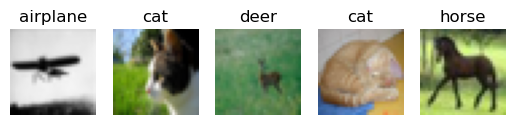

In [21]:
images, labels = next(iter(train_loader))
classes = train_set.classes

for i in range(5):
    img = images[i] / 2 + 0.5  # unnormalize
    npimg = img.numpy().transpose((1, 2, 0))
    plt.subplot(1, 5, i + 1)
    plt.imshow(npimg)
    plt.title(classes[labels[i]])
    plt.axis('off')

plt.show()

#### Customizable CNN Class

Config:
- num_convs: number of convolution + pooling layers
- use_bn: whether to include Batch Normalization
- use_dropout: whether to include Dropout
- activation: choice of activation function (ReLU or LeakyReLU)

In [24]:
class CustomCNN(nn.Module):
    def __init__(self, num_convs=2, use_bn=False, use_dropout=False, activation="relu"):
        super(CustomCNN, self).__init__()
        layers = []

        in_channels = 3
        for i in range(num_convs):
            out_channels = 32 * (2 ** i)
            layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
            if use_bn:
                layers.append(nn.BatchNorm2d(out_channels))
            if activation == "relu":
                layers.append(nn.ReLU())
            elif activation == "leakyrelu":
                layers.append(nn.LeakyReLU(0.1))
            layers.append(nn.MaxPool2d(2))
            if use_dropout:
                layers.append(nn.Dropout(0.25))
            in_channels = out_channels

        self.conv = nn.Sequential(*layers)
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(out_channels * (32 // (2**num_convs))**2, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        return self.fc(x)


#### Training & Evaluation Function

For each model configuration:
- Initializes the model with the given parameters
- Trains for 5 epochs
- Evaluates accuracy on both train and test sets
- Tracks and returns accuracy per epoch

In [30]:
def train_and_evaluate(config, epochs=5):
    model = CustomCNN(**config).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_acc_list, test_acc_list = [], []
    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        train_acc = correct / total
        train_acc_list.append(train_acc)

        # Eval
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        test_acc = correct / total
        test_acc_list.append(test_acc)

        print(f"Epoch {epoch+1}/{epochs}: Train Acc = {train_acc:.4f}, Test Acc = {test_acc:.4f}")
    return train_acc_list, test_acc_list


#### Run 5 Different Experiments

Running 5 experiments:
- Varying Batch Normalization, Dropout, Activation, and number of conv layers.

Each config is tested for 5 epochs.

In [33]:
configs = [
    {"num_convs": 2, "use_bn": False, "use_dropout": False, "activation": "relu"},
    {"num_convs": 2, "use_bn": True,  "use_dropout": False, "activation": "relu"},
    {"num_convs": 2, "use_bn": False, "use_dropout": True,  "activation": "relu"},
    {"num_convs": 3, "use_bn": True,  "use_dropout": True,  "activation": "relu"},
    {"num_convs": 3, "use_bn": True,  "use_dropout": True,  "activation": "leakyrelu"},
]

results = []
for i, cfg in enumerate(configs):
    print(f"\n Running Config {i+1}: {cfg}")
    start = time.time()
    train_acc, test_acc = train_and_evaluate(cfg, epochs=5)
    end = time.time()
    print(f"Time Taken: {end - start:.2f} sec")
    results.append((cfg, test_acc))


 Running Config 1: {'num_convs': 2, 'use_bn': False, 'use_dropout': False, 'activation': 'relu'}
Epoch 1/5: Train Acc = 0.5162, Test Acc = 0.6107
Epoch 2/5: Train Acc = 0.6555, Test Acc = 0.6363
Epoch 3/5: Train Acc = 0.7083, Test Acc = 0.6893
Epoch 4/5: Train Acc = 0.7496, Test Acc = 0.6934
Epoch 5/5: Train Acc = 0.7804, Test Acc = 0.7137
Time Taken: 282.16 sec

 Running Config 2: {'num_convs': 2, 'use_bn': True, 'use_dropout': False, 'activation': 'relu'}
Epoch 1/5: Train Acc = 0.5562, Test Acc = 0.6352
Epoch 2/5: Train Acc = 0.6754, Test Acc = 0.6682
Epoch 3/5: Train Acc = 0.7205, Test Acc = 0.6902
Epoch 4/5: Train Acc = 0.7505, Test Acc = 0.7173
Epoch 5/5: Train Acc = 0.7747, Test Acc = 0.7228
Time Taken: 334.30 sec

 Running Config 3: {'num_convs': 2, 'use_bn': False, 'use_dropout': True, 'activation': 'relu'}
Epoch 1/5: Train Acc = 0.4992, Test Acc = 0.5924
Epoch 2/5: Train Acc = 0.6247, Test Acc = 0.6527
Epoch 3/5: Train Acc = 0.6716, Test Acc = 0.6847
Epoch 4/5: Train Acc = 0.

#### Plot Results

Test Accuracy vs Epochs for each model configuration.

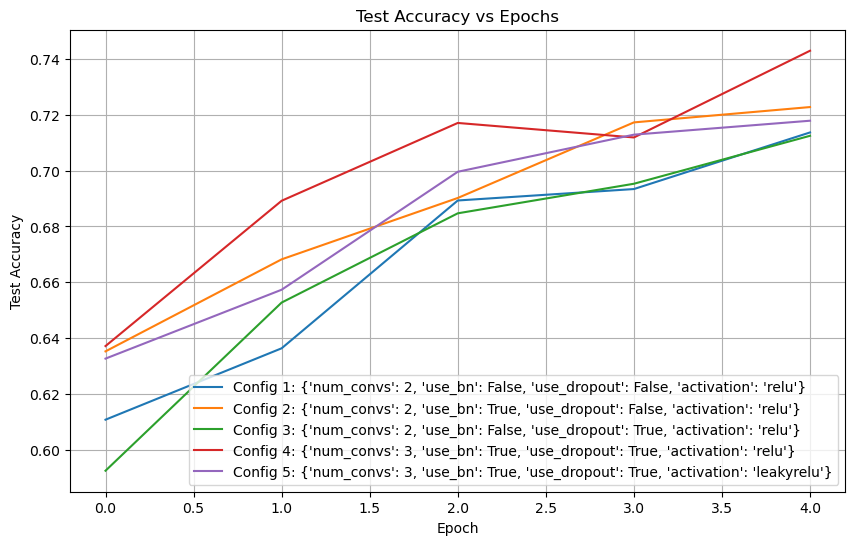

In [35]:
plt.figure(figsize=(10, 6))
for i, (cfg, acc) in enumerate(results):
    plt.plot(acc, label=f"Config {i+1}: {cfg}")
plt.title("Test Accuracy vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy")
plt.legend()
plt.grid(True)
plt.show()


#### Final Summary

the final accuracy of each experiment to help choose the best model.

In [37]:
print("\n Final Test Accuracies Summary:")
for i, (cfg, acc) in enumerate(results):
    print(f"Config {i+1}: {cfg}")
    print(f"Final Test Accuracy: {acc[-1]:.4f}\n")


 Final Test Accuracies Summary:
Config 1: {'num_convs': 2, 'use_bn': False, 'use_dropout': False, 'activation': 'relu'}
Final Test Accuracy: 0.7137

Config 2: {'num_convs': 2, 'use_bn': True, 'use_dropout': False, 'activation': 'relu'}
Final Test Accuracy: 0.7228

Config 3: {'num_convs': 2, 'use_bn': False, 'use_dropout': True, 'activation': 'relu'}
Final Test Accuracy: 0.7125

Config 4: {'num_convs': 3, 'use_bn': True, 'use_dropout': True, 'activation': 'relu'}
Final Test Accuracy: 0.7430

Config 5: {'num_convs': 3, 'use_bn': True, 'use_dropout': True, 'activation': 'leakyrelu'}
Final Test Accuracy: 0.7179

